Linear Regression


Saving household_dataset.csv to household_dataset.csv
         date  month  is_weekend  num_appliances_used  peak_hour_usage  \
0  01-01-2019      1           0                    4            3.799   
1  02-01-2019      1           0                    5            3.094   
2  03-01-2019      1           0                    5            3.157   
3  04-01-2019      1           0                    5            4.305   
4  05-01-2019      1           1                    6            4.136   

   off_peak_usage  daily_kwh  monthly_kwh  monthly_bill  usage_label  
0           2.710      8.211       243.79       1587.13            0  
1           2.765      8.076       243.79       1587.13            0  
2           2.326      6.806       243.79       1587.13            0  
3           2.623      8.766       243.79       1587.13            1  
4           3.079      8.000       243.79       1587.13            0  
Dataset shape: (2000, 10)

MSE: 2768.15
RMSE: 52.61

If next month usage = 

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


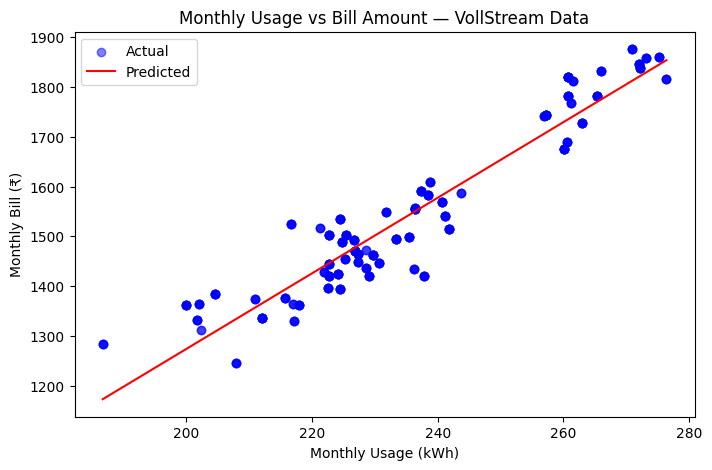

In [8]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt


from google.colab import files
uploaded = files.upload()

df = pd.read_csv('household_dataset.csv')
print(df.head())
print(f"Dataset shape: {df.shape}")

# Features and target
X = df[['monthly_kwh']] #input
y = df['monthly_bill'] #output

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Train
model = LinearRegression()
model.fit(X_train, y_train)

# Predict
predictions = model.predict(X_test)
mse = mean_squared_error(y_test, predictions)
print(f"\nMSE: {mse:.2f}")
print(f"RMSE: {np.sqrt(mse):.2f}")

# Predict next month
next_month_kwh = 300
prediction_next_month = model.predict([[next_month_kwh]]).item()
print(f"\nIf next month usage = {next_month_kwh} kWh")
print(f"Predicted bill = ₹{prediction_next_month:.0f}")

# Plot
plt.figure(figsize=(8,5))
plt.scatter(X_test, y_test, color='blue', label='Actual', alpha=0.5)
plt.plot(X_test.sort_values('monthly_kwh'),
         model.predict(X_test.sort_values('monthly_kwh')),
         color='red', label='Predicted')
plt.title('Monthly Usage vs Bill Amount — VollStream Data')
plt.xlabel('Monthly Usage (kWh)')
plt.ylabel('Monthly Bill (₹)')
plt.legend()
plt.show()

Logistic Regression

Accuracy: 99.5%

Classification Report:
              precision    recall  f1-score   support

   Low Usage       1.00      0.99      1.00       272
  High Usage       0.98      1.00      0.99       128

    accuracy                           0.99       400
   macro avg       0.99      1.00      0.99       400
weighted avg       1.00      0.99      1.00       400


Confusion Matrix:
[[270   2]
 [  0 128]]


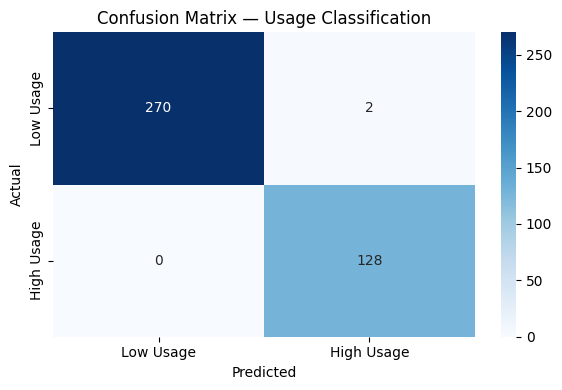


Test: daily_kwh=8.5, peak=4.2, appliances=6
Prediction → High Usage 🔴


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Features and target
X2 = df[['daily_kwh', 'peak_hour_usage', 'num_appliances_used']]
y2 = df['usage_label']

# Split
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42)

# Train, then the classifier
clf = LogisticRegression(max_iter=1000)
clf.fit(X2_train, y2_train)

# Predict
y2_pred = clf.predict(X2_test)

# Accuracy
accuracy = accuracy_score(y2_test, y2_pred)
print(f"Accuracy: {accuracy * 100:.1f}%")
print(f"\nClassification Report:")
print(classification_report(y2_test, y2_pred,
      target_names=['Low Usage', 'High Usage']))

# Confusion Matrix
cm = confusion_matrix(y2_test, y2_pred)
print(f"\nConfusion Matrix:")
print(cm)

# Plot
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Low Usage', 'High Usage'],
            yticklabels=['Low Usage', 'High Usage'])
plt.title('Confusion Matrix — Usage Classification')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# Test a prediction
test_input = [[8.5, 4.2, 6]]
result = clf.predict(test_input)[0]
label = "High Usage 🔴" if result == 1 else "Low Usage 🟢"
print(f"\nTest: daily_kwh=8.5, peak=4.2, appliances=6")
print(f"Prediction → {label}")